# Question 1
Given following membership functions for fuzzy set Old and Young 
Where, x is the age of the Person. Calculate the value of the following:
μ_young(x) = bell(x, 20, 2, 40)
μ_old(x) = bell(x, 30, 3, 100)
- More or less young
- Not young and not old
- Young but not too young
- Extremely old

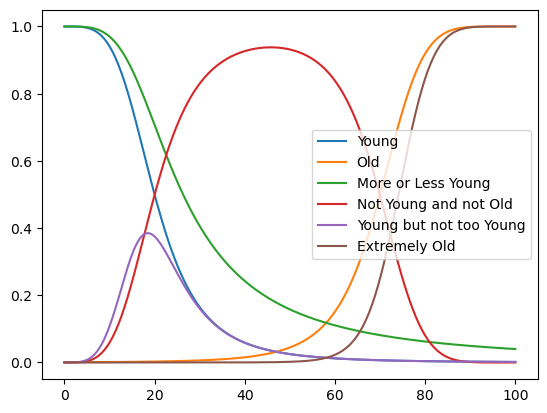

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def bell(x, a, b, c):
    return 1/(1+np.abs((x-c) / a)**(2*b))

x = np.linspace(0, 100, 300)
mu_young = bell(x, 20, 2, 0)
mu_old = bell(x, 30, 3, 100)

more_or_less_young = np.sqrt(mu_young)
not_young_and_not_old = (1 - mu_young)*(1 - mu_old)
young_but_not_too_young = mu_young * (1-np.power(mu_young, 2))
extremely_old = np.power(mu_old, 2)

plt.plot(x, mu_young, label="Young")
plt.plot(x, mu_old, label="Old")
plt.plot(x, more_or_less_young, label="More or Less Young")
plt.plot(x, not_young_and_not_old, label="Not Young and not Old")
plt.plot(x, young_but_not_too_young, label="Young but not too Young")
plt.plot(x, extremely_old, label="Extremely Old")
plt.legend()
plt.show()

# Question 2
Given following relations:
R1 = "x is relevant to y", R2 = "y is relevant to z"
Where X = {1, 2, 3}, Y = {a, b, c, d}, Z = {One, two}
Assuming appropriate values for R1 and R2, Calculate the max-min and 
max Product composition for (3, one).

In [6]:
import numpy as np

X = [1,2,3]
Y = ['a','b','c','d']
Z = ['One', 'two']

R1 = np.array([
    [0.2,0.6,0.8,0.4],
    [0.9,0.1,0.5,0.7],
    [0.3,0.4,0.6,0.9]
])

R2 = np.array([
    [0.7,0.2],
    [0.5,0.0],
    [0.6,0.3],
    [0.8,0.4]
])

i = X.index(3)
k = Z.index('One')

max_min = np.max(np.minimum(R1[i, :], R2[:, k]))

max_prod = np.max(np.round(R1[i, :]*R2[:, k] ,2))

print("Max-min composition (3,One):", max_min)
print("Max_product composition (3, One):", max_prod)


Max-min composition (3,One): 0.8
Max_product composition (3, One): 0.72


# Question 3
Take different element of a fuzzy Set as user input and defuzzify using 
Bisector of area, Centroid of area, Mean of Maximum and Smallest of maximum.


In [7]:
# Input fuzzy set
fuzzy_set = [(1, 0.2), (2, 0.5), (3, 0.9), (4, 0.7), (5, 0.3)]

# Centroid
num = sum(x * mu for x, mu in fuzzy_set)
den = sum(mu for _, mu in fuzzy_set)
centroid = num / den

# Bisector
total_area = den
half_area = total_area / 2
cum_area = 0
bisector = None

for x, mu in fuzzy_set:
    cum_area += mu
    if cum_area >= half_area:
        bisector = x
        break

# Mean of Maxima
max_mu = max(mu for _, mu in fuzzy_set)
max_x = [x for x, mu in fuzzy_set if mu == max_mu]
mom = sum(max_x) / len(max_x)

# Smallest of Maxima
som = min(max_x)

print("Centroid:", centroid)
print("Bisector:", bisector)
print("Mean of Maxima:", mom)
print("Smallest of Maxima:", som)


Centroid: 3.1538461538461533
Bisector: 3
Mean of Maxima: 3.0
Smallest of Maxima: 3


# Question 4
Given, following rules:
R1: If BP is high and temperature is high then health is Poor
R2: If BP is normal and temperature is normal then health is Good
R3: If BP is low and temperature is normal the health is Normal
Take the value of Blood Pressure and Temp as User input and determine health.


In [13]:
def trapmf(x, a, b, c, d):
    if x <= a or x >= d: return 0.0
    elif a <= x <= b: return (x - a) / (b - a)
    elif b <= x <= c: return 1.0
    elif c <= x <= d: return (d - x) / (d - c)

def trimf(x, a, b, c):
    if x <= a or x >= c: return 0.0
    elif a < x <= b: return (x - a) / (b - a)
    elif b < x < c: return (c - x) / (c - b)

bp = float(input("Enter Blood Pressure: "))
temp = float(input("Enter Temperature: "))

# Fuzzify BP
bp_low = trapmf(bp, 0, 0, 60, 90)
bp_normal = trimf(bp, 80, 110, 130)
bp_high = trapmf(bp, 120, 140, 200, 200)

# Fuzzify Temperature
temp_normal = trimf(temp, 35, 37, 38)
temp_high = trapmf(temp, 37.5, 39, 45, 45)

# Rule 1: High BP and High Temp -> Poor
rule1_poor = min(bp_high, temp_high)

# Rule 2: Normal BP and Normal Temp -> Good
rule2_good = min(bp_normal, temp_normal)

# Rule 3: Low BP and Normal Temp -> Normal
rule3_normal = min(bp_low, temp_normal)

# Simple Centroid Defuzzification (singletons: Poor=20, Normal=50, Good=80)
total_weight = rule1_poor + rule2_good + rule3_normal

if total_weight > 0:
    health_score = (rule1_poor * 20 + rule3_normal * 50 + rule2_good * 80) / total_weight
    print(f"\nRule Firing Strengths:")
    print(f"Poor: {rule1_poor}")
    print(f"Normal: {rule3_normal}")
    print(f"Good: {rule2_good}")
    print(f"\nDetermined Health Score: {health_score:.2f}")
else:
    print("Health Status is undefined for this input.")


Health Status is undefined for this input.


# Question 5
Consider a universe representing room temperature in degree C and 
other universe representing relative humidity given by:
T = 0.4/16 + 0.8/18 + 1.0/20 + 1.0/22 + 0.8/24 + 0.5/26
H = 0.2/0 + 0.8/20 + 1.0/40 + 0.6/60 + 0.2/80
Calculate the membership of "Acceptable Temperature OR Acceptable Humidity"


In [ ]:
T = {16: 0.4, 18: 0.8, 20: 1.0, 22: 1.0, 24: 0.8, 26: 0.5}
H = {0: 0.2, 20: 0.8, 40: 1.0, 60: 0.6, 80: 0.2}

print("Acceptable Temperature OR Acceptable Humidity (Union)")
print("-" * 55)

print(f"{'Temperature':<15} {'Humidity':<15} {'Union Membership (max)'}")
print("-" * 55)

for t_val, t_mu in T.items():
    for h_val, h_mu in H.items():
        union_mu = max(t_mu, h_mu)
        print(f"T={t_val:<13} H={h_val:<13} {union_mu}")


Acceptable Temperature OR Acceptable Humidity (Union)
-------------------------------------------------------
Temperature     Humidity        Union Membership (max)
-------------------------------------------------------
T=16            H=0             0.4
T=16            H=20            0.8
T=16            H=40            1.0
T=16            H=60            0.6
T=16            H=80            0.4
T=18            H=0             0.8
T=18            H=20            0.8
T=18            H=40            1.0
T=18            H=60            0.8
T=18            H=80            0.8
T=20            H=0             1.0
T=20            H=20            1.0
T=20            H=40            1.0
T=20            H=60            1.0
T=20            H=80            1.0
T=22            H=0             1.0
T=22            H=20            1.0
T=22            H=40            1.0
T=22            H=60            1.0
T=22            H=80            1.0
T=24            H=0             0.8
T=24            H=20   